In [3]:
#manual install the latest landsatxplore from source code https://github.com/yannforget/landsatxplore

In [4]:
import json
from landsatxplore.api import API

username = "zliu1208"
password = "L,FTSF2.VZMzS5,"
# Initialize a new API instance and get an access key
api = API(username, password)

## search for scenes

In [ ]:
# Search for Landsat TM scenes
scenes = api.search(
    dataset='landsat_ot_c2_l1',
    latitude=38.98,
    longitude=-76.93,
    start_date='2022-10-01',
    end_date='2022-10-31'
)

print(f"{len(scenes)} scenes found.")

In [ ]:
# Process the result
for scene in scenes:
    print(scene['acquisition_date'].strftime('%Y-%m-%d'))
    # Write scene footprints to disk
    fname = f"{scene['landsat_product_id']}.geojson"
    with open(fname, "w") as f:
        json.dump(scene['spatial_coverage'].__geo_interface__, f)

api.logout()

## download scenes

In [ ]:
from landsatxplore.earthexplorer import EarthExplorer

ee = EarthExplorer(username, password)

In [ ]:
ee.download('LC08_L1TP_015033_20221007_20221013_02_T1','./data')

In [ ]:
ee.logout()

In [ ]:
ee.download('LT51960471995178MPS00', output_dir='./data')

ee.logout()

## reference list



In [7]:
import geopandas as gpd

In [8]:
gdf = gpd.read_file("../../../web3-geo-dashboard/data_processing/landsat_scenes_intersecting_continential_us.geojson")

In [9]:
gdf

,PATH,ROW,index_right,STUSPS,geometry
0,13,27,47,ME,"POLYGON ((-72.34003 46.87432, -72.34060 46.874..."
1,13,28,47,ME,"POLYGON ((-72.83752 45.44983, -72.83800 45.449..."
2,13,29,47,ME,"POLYGON ((-73.31624 44.02363, -73.31670 44.023..."
3,11,27,47,ME,"POLYGON ((-69.24993 46.87432, -69.25050 46.874..."
4,11,28,47,ME,"POLYGON ((-69.74742 45.44983, -69.74790 45.449..."
...,...,...,...,...,...
860,14,32,2,DE,"POLYGON ((-76.20173 39.73586, -76.20200 39.735..."
861,14,33,2,DE,"POLYGON ((-76.62123 38.30385, -76.62160 38.303..."
862,15,32,2,DE,"POLYGON ((-77.74673 39.73585, -77.74710 39.735..."
863,15,33,2,DE,"POLYGON ((-78.16633 38.30386, -78.16660 38.303..."


In [10]:
#only keep a unique PATH-ROW
gdf = gdf.drop_duplicates(subset=['PATH','ROW'])

<AxesSubplot: >

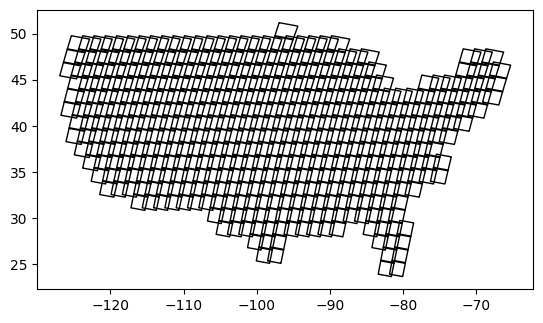

In [11]:
gdf.plot( facecolor='none')

In [12]:
# Compute the centroids
gdf['centroid'] = gdf['geometry'].centroid

# Extract lat and lon from centroid
gdf['lat'] = gdf['centroid'].apply(lambda point: point.y)
gdf['lon'] = gdf['centroid'].apply(lambda point: point.x)

# Print the dataframe
gdf.head()

/tmp/ipykernel_297407/409405552.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf['geometry'].centroid
/gpfs/data1/oshangp/easier/easier/venv/lib/python3.8/site-packages/geopandas/geodataframe.py:1472: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/gpfs/data1/oshangp/easier/easier/venv/lib/python3.8/site-packages/geopandas/geodataframe.py:1472: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

,PATH,ROW,index_right,STUSPS,geometry,centroid,lat,lon
0,13,27,47,ME,"POLYGON ((-72.34003 46.87432, -72.34060 46.874...",POINT (-70.86923 47.45135),47.451354,-70.869231
1,13,28,47,ME,"POLYGON ((-72.83752 45.44983, -72.83800 45.449...",POINT (-71.40724 46.03211),46.032108,-71.407243
2,13,29,47,ME,"POLYGON ((-73.31624 44.02363, -73.31670 44.023...",POINT (-71.92346 44.61074),44.610737,-71.923455
3,11,27,47,ME,"POLYGON ((-69.24993 46.87432, -69.25050 46.874...",POINT (-67.77913 47.45135),47.451354,-67.779131
4,11,28,47,ME,"POLYGON ((-69.74742 45.44983, -69.74790 45.449...",POINT (-68.31714 46.03211),46.032108,-68.317143


In [13]:
scene_selection = []
for idx,pathrow in gdf.iterrows():
    
    # Search for Landsat TM scenes
    scenes = api.search(
        dataset='landsat_ot_c2_l1',
        latitude=pathrow['lat'],
        longitude=pathrow['lon'],
        start_date='2022-10-01',
        end_date='2022-10-31'
    )
    #print(f"{pathrow['PATH']},{pathrow['ROW']} {len(scenes)} scenes found.")
    for scene in scenes:
        if scene['satellite'] == 9:
            #print(scene['landsat_product_id'])
            scene_selection.append(scene['landsat_product_id'])
            break

In [14]:
len(scene_selection)

457

In [15]:
with open(f'scenes.txt', 'w') as fp:
    fp.write("landsat_ot_c2_l1|displayId\n")
    for item in scene_selection:
        # write each item on a new line
        fp.write(f"{item}\n")

In [5]:
from landsatxplore.earthexplorer import EarthExplorer

ee = EarthExplorer(username, password)

In [ ]:
scene_selection

In [6]:
ee.download('LC09_L1TP_022039_20221016_20230325_02_T1','./data')

100%|█████████████████████████████████| 1.19G/1.19G [01:23<00:00, 15.2MB/s]


'./data/LC09_L1TP_022039_20221016_20230325_02_T1.tar'

In [ ]:
for prd in scene_selection:
    ee.download(prd,'./data')

In [ ]:
ee.logout()

In [16]:
import os

path = "../../data/landsat/m2m_download/20221017/"
subfolders = [f.name for f in os.scandir(path) if f.is_dir()]

print(subfolders)


['LC09_L1TP_029029_20221017_20230325_02_T1', 'LC09_L1TP_029034_20221017_20230325_02_T1', 'LC09_L1TP_029028_20221017_20230325_02_T1', 'LC09_L1TP_029026_20221017_20230325_02_T1', 'LC09_L1GT_029039_20221017_20230325_02_T2', 'LC09_L1TP_013029_20221017_20230325_02_T1', 'LC09_L1GT_013031_20221017_20230325_02_T2', 'LC09_L1TP_029035_20221017_20230325_02_T1', 'LC09_L1TP_013036_20221017_20230325_02_T1', 'LC09_L1GT_029040_20221017_20230325_02_T2', 'LC09_L1GT_013030_20221017_20230325_02_T2', 'LC09_L1TP_029031_20221017_20230325_02_T1', 'LC09_L1TP_029032_20221017_20230325_02_T1', 'LC09_L1TP_029030_20221017_20230325_02_T1', 'LC09_L1TP_029037_20221017_20230325_02_T1', 'LC09_L1TP_013032_20221017_20230325_02_T1', 'LC09_L1GT_134212_20221017_20230325_02_T2', 'LC09_L1TP_013027_20221017_20230325_02_T1', 'LC09_L1TP_013028_20221017_20230325_02_T1', 'LC09_L1TP_029036_20221017_20230325_02_T1', 'LC09_L1TP_045026_20221017_20230325_02_T1', 'LC09_L1TP_045031_20221017_20230325_02_T1', 'LC09_L1GT_029038_20221017_2023